In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import random
from collections import deque
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F

C_DQN  = "dodgerblue"
C_HEUR = "darkorange"

pi = np.pi

import drqn as dqn
import hex_world_procedural_senses as hex_world
import oracle_v2 as oracle

from sweep_fn_4 import *
from plot_fn_4 import *

In [2]:
# ===== DRQN n-step smoke cell =====
import numpy as np, torch
import drqn as dqn
from sweep_fn_4 import slim_run, build_config
from sim_instance_v1 import sim_instance

# ---- PART A: n-step target correctness on a toy batch (the bug-prone bit) ----
# Hand-built: 1 sequence, known rewards, a DONE planted mid-window.
# Confirms n-step sums forward, cuts at done, bootstraps at the right index.
torch.manual_seed(0)
B, T, A, H = 1, 8, 13, 64
model, opt = dqn.noisy_drqn_make_model(20, H, A, lr=0.01, sigma_0=0.5)
target = dqn.noisy_drqn_make_target(model)

rewards = np.zeros((B, T), dtype=np.float32); rewards[0] = [1,1,1,1,1,1,1,1]
dones   = np.zeros((B, T), dtype=bool);       dones[0, 3] = True   # death at t=3
batch = {
    "states":      np.random.randn(B, T, 20).astype(np.float32),
    "actions":     np.zeros((B, T), dtype=np.int64),
    "rewards":     rewards,
    "next_states": np.random.randn(B, T, 20).astype(np.float32),
    "dones":       dones,
    "next_masks":  np.ones((B, T, A), dtype=bool),
    "valid":       np.ones((B, T), dtype=bool),
}

# run learn step at n=1 and n=10, capture loss (proxy: they must differ)
torch.manual_seed(1); m1,o1 = dqn.noisy_drqn_make_model(20,H,A,lr=0.01,sigma_0=0.5); t1=dqn.noisy_drqn_make_target(m1)
torch.manual_seed(1); m2,o2 = dqn.noisy_drqn_make_model(20,H,A,lr=0.01,sigma_0=0.5); t2=dqn.noisy_drqn_make_target(m2)
l1 = dqn.drqn_learn_step(m1, t1, o1, batch, gamma=0.99, burn_in=0, n_step=1)
l2 = dqn.drqn_learn_step(m2, t2, o2, batch, gamma=0.99, burn_in=0, n_step=10)
print(f"[A] loss n=1: {l1:.4f}   loss n=10: {l2:.4f}   differ: {abs(l1-l2) > 1e-6}")
assert abs(l1 - l2) > 1e-6, "n_step NOT wired — same loss means n_step ignored"

# ---- PART B: end-to-end short run, the four plumbing assertions ----
out = sim_instance(
    seed=0, model_type="noisy_drqn_DQN", n_step=10,
    sim_len=20_000, eval_len=2_000,
    senses=("smell","vision"), midpoint_probe=True,
    env_kwargs={"radius":20},
    replay_warmup=200, replay_archive_len=500, batch_size=64,
    drqn_burn_in=5, drqn_learn_len=20,
)

sig = out["sigma_w_mean"]
print(f"[B1] sigma logged: {len(sig)}  (must be > 0)")
print(f"[B2] sigma first/last: {sig[0]:.4f} / {sig[-1]:.4f}  moves: {abs(sig[0]-sig[-1]) > 1e-4}")
assert len(sig) > 0, "sigma not logged — gate still excludes noisy_drqn_DQN"
assert abs(sig[0] - sig[-1]) > 1e-4, "sigma frozen — noise params not training"

# slim must carry sigma through to disk
cfg = build_config(base_env={"radius":20},
                   base_sim={"sim_len":20_000,"eval_len":2_000},
                   base_agent={"model_type":"noisy_drqn_DQN"})
slim = slim_run(out, cfg, seed=0, train_fn=sim_instance)
print(f"[B3] sigma in slim: {'sigma_w_mean' in slim}")
assert "sigma_w_mean" in slim, "slim_run drops sigma — add the carry line"

print(f"[B4] ran clean: mean={out['mean_comfort']:.3f} eval_deaths={out['death_count_eval']}")
print("ALL SMOKE CHECKS PASSED")

[A] loss n=1: 0.5619   loss n=10: 1.8587   differ: True
[B1] sigma logged: 900  (must be > 0)
[B2] sigma first/last: 0.0625 / 0.0589  moves: True
[B3] sigma in slim: True
[B4] ran clean: mean=0.379 eval_deaths=56
ALL SMOKE CHECKS PASSED


In [2]:
#region BAND ENFORCEMENT CHECK
import numpy as np
import pandas as pd

CHECK_SEEDS = range(20)
RADIUS = 20
BAND = (9, 11)
band_min, band_max = BAND

rows = []
for s in CHECK_SEEDS:
    try:
        w = hex_world.HexWorld(seed=s, radius=RADIUS, band=BAND)
    except ValueError as e:
        rows.append({"seed": s, "built": False, "min_pair": np.nan,
                     "n_water": np.nan, "n_food": np.nan, "err": str(e)[:60]})
        continue

    wc, fc = w.water_coords, w.food_coords
    # independent recompute — don't trust the internal affirmation alone
    min_pair = min(hex_world.HexWorld.hex_dist(f, ww) for f in fc for ww in wc)
    rows.append({
        "seed": s, "built": True, "min_pair": min_pair,
        "n_water": len(wc), "n_food": len(fc),
        "foods_per_hub": round(len(fc) / max(len(wc), 1), 2),
        "err": "",
    })

chk = pd.DataFrame(rows)
print(chk.to_string(index=False))

ok = chk[chk.built]
fail_build = chk[~chk.built]
fail_band  = ok[ok.min_pair < band_min]

print(f"\nfloor = band_min = {band_min}")
print(f"built ok:        {len(ok)}/{len(chk)}")
print(f"min_pair >= {band_min}: {len(ok) - len(fail_band)}/{len(ok)}")
if len(ok):
    print(f"min_pair distribution: min {ok.min_pair.min():.0f}  "
          f"median {ok.min_pair.median():.0f}  max {ok.min_pair.max():.0f}")
    print(f"hubs/map: {ok.n_water.min():.0f}-{ok.n_water.max():.0f}  "
          f"foods/map: {ok.n_food.min():.0f}-{ok.n_food.max():.0f}  "
          f"foods/hub median: {ok.foods_per_hub.median():.1f}")

if len(fail_build):
    print(f"\nBUILD FAILURES (affirmation raised): seeds {list(fail_build.seed)}")
    for _, r in fail_build.iterrows():
        print(f"  seed {r.seed}: {r.err}")
if len(fail_band):
    print(f"\nBAND LEAKS (built but min_pair < {band_min}): seeds {list(fail_band.seed)}")
    print("  -> internal affirmation did NOT fire — the raise is wrong, not the map")

print("\nverdict:", "PASS — band enforced on all seeds"
      if (len(fail_build) == 0 and len(fail_band) == 0)
      else "FAIL — see above")
#endregion

 seed  built  min_pair  n_water  n_food  foods_per_hub err
    0   True         9        3       8           2.67    
    1   True         9        4      11           2.75    
    2   True         9        4       9           2.25    
    3   True         9        4      11           2.75    
    4   True         9        4      11           2.75    
    5   True         9        3       8           2.67    
    6   True         9        4      11           2.75    
    7   True         9        5      12           2.40    
    8   True         9        3       9           3.00    
    9   True         9        4      11           2.75    
   10   True         9        3       8           2.67    
   11   True         9        4      10           2.50    
   12   True         9        4      11           2.75    
   13   True         9        4      11           2.75    
   14   True         9        4       9           2.25    
   15   True         9        3       7           2.33  

In [ ]:
import hex_world_procedural as hex_world
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

from plot_fn_4 import make_hex_coords, axial_to_xy, hex_vertices, _draw_resource_outlines

RADIUS = 20
BAND   = (9, 11)
SEEDS  = range(6)

all_coords = make_hex_coords(RADIUS)
xs, ys = zip(*[axial_to_xy(q, r) for q, r in all_coords])

fig, axes = plt.subplots(2, 3, figsize=(16, 11))
for ax, seed in zip(axes.flat, SEEDS):
    env = hex_world.HexWorld(seed=seed, radius=RADIUS, band=BAND)

    # base map: faint empty hexes
    for q, r in all_coords:
        x, y = axial_to_xy(q, r)
        ax.add_patch(Polygon(hex_vertices(x, y, scale=1.003), closed=True,
                             facecolor="#ececec", edgecolor="#ececec",
                             linewidth=0.0, antialiased=False))

    # draw the 9-11 commute bands around each water, faint
    for w in env.water_coords:
        for c in hex_world.HexWorld.hex_neighbors(w, BAND[0], BAND[1]):
            if c in env.nodes:
                x, y = axial_to_xy(*c)
                ax.add_patch(Polygon(hex_vertices(x, y, scale=1.003), closed=True,
                                     facecolor="#d8e8f0", edgecolor="#d8e8f0",
                                     linewidth=0.0, antialiased=False, zorder=1))

    _draw_resource_outlines(ax, env.water_coords, env.food_coords)

    ax.set_xlim(min(xs) - 1.5, max(xs) + 1.5)
    ax.set_ylim(min(ys) - 1.5, max(ys) + 1.5)
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(f"seed {seed}  |  {len(env.water_coords)} water, "
                 f"{len(env.food_coords)} food", fontsize=10)

fig.suptitle("water-first procedural worlds — blue = water (hub), orange = food (satellites)\n"
             "shaded ring = 9-11 commute band", fontsize=13)
plt.tight_layout()
plt.show()

In [3]:
PROTOTYPE_NAME = "04_generalisation"
EXPERIMENT_NAME = PROTOTYPE_NAME + "__" + "DRQN_vs_FF_matched_n10_v2"

res, manifest, runs_df, summary_df = load_and_report(EXPERIMENT_NAME, PROTOTYPE_NAME)

loaded experiment: 04_generalisation__DRQN_vs_FF_matched_n10_v2
configs: 2   runs: 80


,config,solved,95% wilson,clean,comfort_med,deaths_med,zero_death,food%,water%
0,noisy_drqn__n_step_10__b_64__buf_1k,0% (0/40),[-0%–9%],25%,0.41,530.5,0%,0.6,0.2
1,noisy__n_step_10__b_64__buf_50k,0% (0/40),[-0%–9%],32%,0.41,532.0,0%,0.6,0.2



config reports:

CONFIG: noisy_drqn__n_step_10__b_64__buf_1k
Solved rate: 0.0% (0/40 seeds), 95% Wilson [-0.0%, 8.8%].
Clean-solve (crossed the valley, no death cap): 25.0% (10/40) — the gap to solved is the survival cost of the crossing.
Comfort: median 0.409, mean 0.409, std 0.012, range 0.377 to 0.439.
Deaths: median 530.5, mean 528.8, range 491 to 574, zero-death rate 0.0%.
Resource occupancy: food 0.56%, water 0.20%, water:food ratio 0.42.
Camp shape: water-camp score -0.29, dominant-cell occupancy 3.08%.
Water→food route: success rate 0.043, success count median 2.0, path efficiency 0.778, perfect-ish trip rate 0.250.
Food→water route: success rate 0.012, success count median 1.5, path efficiency 0.756.
Two-way route floor: 0.010; total successful resource trips median 3.0.
Bug check: max non-neighbour jumps = 0.

CONFIG: noisy__n_step_10__b_64__buf_50k
Solved rate: 0.0% (0/40 seeds), 95% Wilson [-0.0%, 8.8%].
Clean-solve (crossed the valley, no death cap): 32.5% (13/40) — the g

corr(hyd_frac, food%) : 0.456
corr(hyd_frac, deaths): 0.697

=== MASKING (winners rim-localised, fewer legal actions) ===
  edge_proximity : win nan  die 0.745   corr=+nan
  mean_legal_act : win nan   die 7.95    corr=+nan
=== TIGHTNESS (winners got tighter best cluster) ===
  tightest_clust : win nan   die 5.15    corr=+nan

 seed  edge_proximity  tightest_cluster  mean_legal_actions  dom_hub_dist  solved  food_visit_pct  eval_deaths
    0            0.90                 3              7.8242            18       0           0.860          294
    1            0.80                 4              7.8052            16       0           1.210          318
   10            0.50                 4              7.9524            10       0           3.680          276
   11            0.95                 7              8.3114            19       0           1.070          255
   12            0.85                 7              7.6316            17       0           1.225          338
   13 

c:\Users\Adarsh Arun\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Adarsh Arun\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


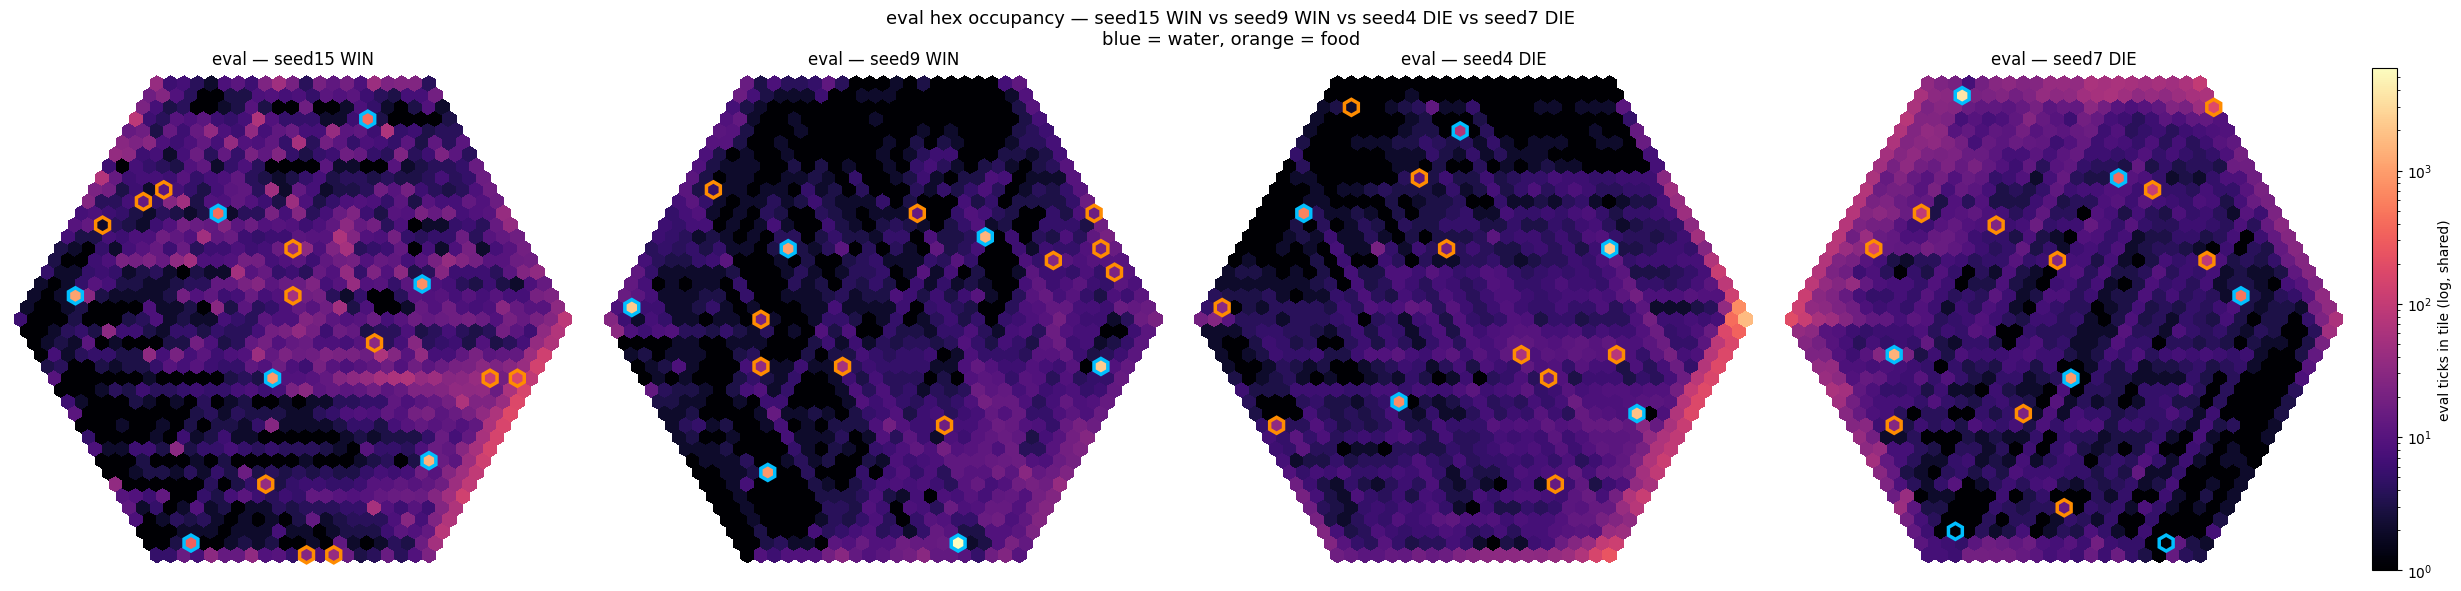

saved: c:\Users\Adarsh Arun\Downloads\homeostatic-agents-main\results\best_figures\cmp_death_gaps_eval_seed15 WIN_vs_seed9 WIN_vs_seed4 DIE_vs_seed7 DIE.png


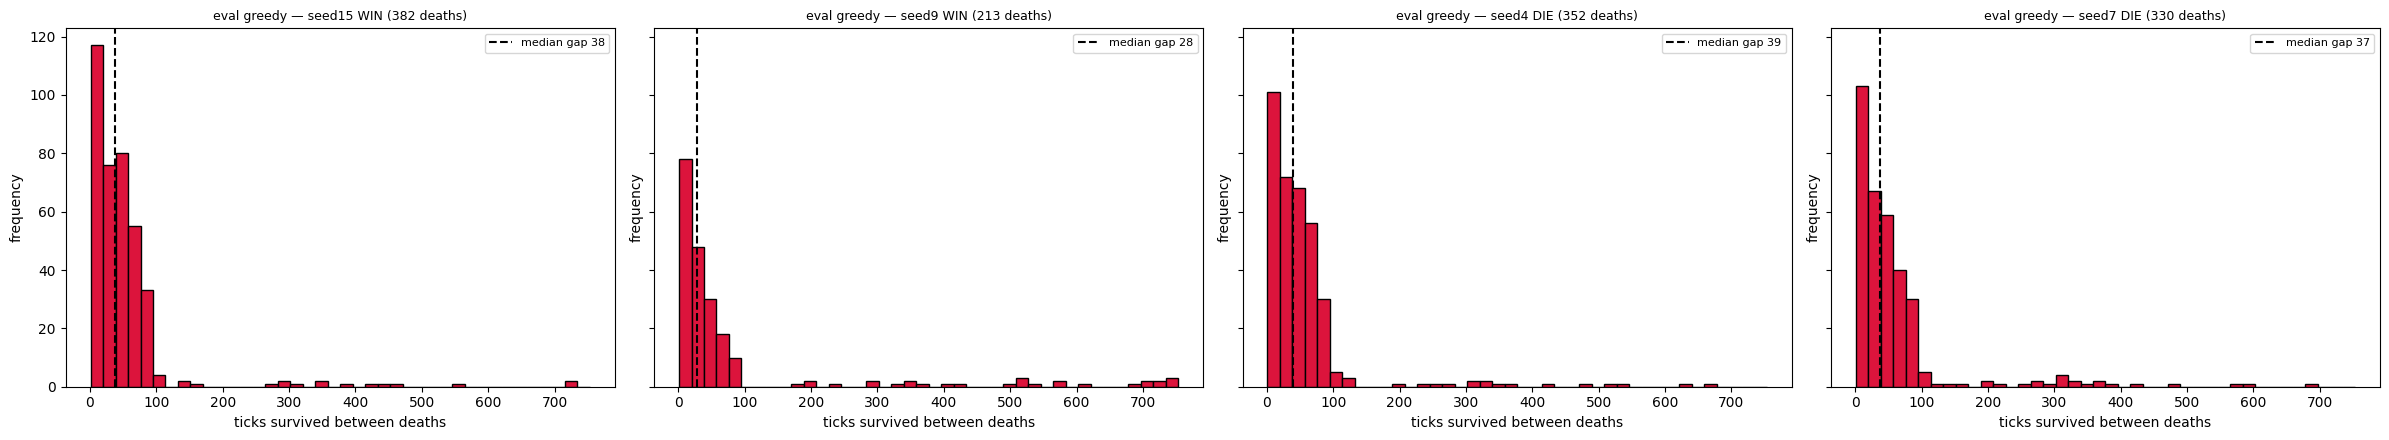

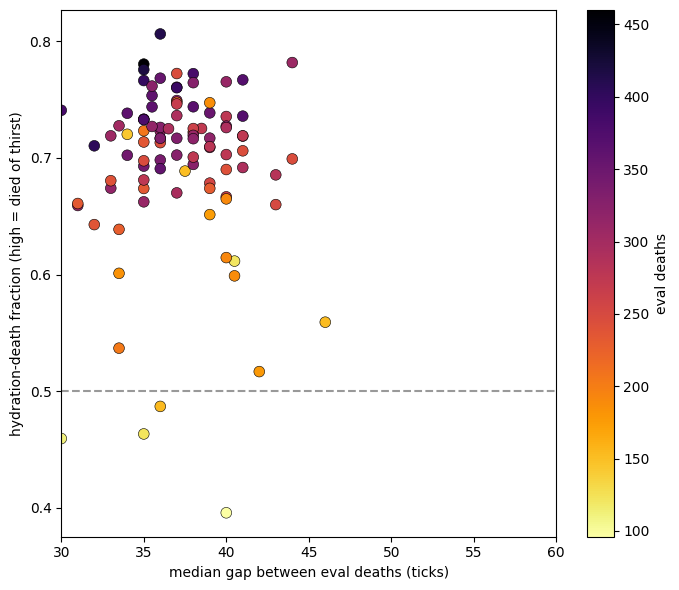

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hex_world_procedural as hex_world   

# =====================================================================
# SETUP — load the sweep, shared handles
# =====================================================================
EXPERIMENT_NAME = "04_generalisation__motivation_noisy_procedural_v3"
PROTOTYPE_NAME = "04_generalisation"

grouped, manifest = load_sweep(EXPERIMENT_NAME, PROTOTYPE_NAME, recompute_metrics=False)

# runs_df: load from the sweep's CSV, or rebuild
runs_df = pd.read_csv(sweep_dir(EXPERIMENT_NAME, PROTOTYPE_NAME) / "runs_df.csv")

config_name = next(iter(grouped))
runs = grouped[config_name]["runs"]

def seed_of(r):
    return r.get("seed", r.get("sim_kwargs", {}).get("seed"))

by_seed = {seed_of(r): r for r in runs}

# winners = low-death solvers, diers = high thirst-death
PICKS = [
    ("seed15 WIN", by_seed[15]),
    ("seed9 WIN",  by_seed[9]),
    ("seed4 DIE",  by_seed[4]),
    ("seed7 DIE",  by_seed[7]),
]

# solved flag (strict gate) on runs_df, used downstream
pe = pd.to_numeric(runs_df["path_efficiency"], errors="coerce")
pf = pd.to_numeric(runs_df["perfectish_trip_rate"], errors="coerce")
dd = pd.to_numeric(runs_df["eval_deaths"], errors="coerce")
runs_df = runs_df.assign(solved=((pe >= 0.9) & (pf > 0) & (dd <= 5)).astype(int))


# =====================================================================
# region DEATH CAUSE + TIMING  — rebuild from death_T + h/s arrays
# (death_events not persisted to pkls; reconstruct, counts reconcile
#  with death_count_eval)
# =====================================================================
DEATH_THR = 0.05   # matches sim's cur_dead threshold (h<=0.05 or s<=0.05)

rows = []
for r in runs:
    seed = seed_of(r)
    death_T = np.asarray(r["death_T"]).astype(bool)
    eb = int(r.get("eval_boundary", len(r["comfort_train"])))

    eval_death_idx = np.flatnonzero(death_T[eb:])   # death positions within eval
    n = len(eval_death_idx)

    if n == 0:
        rows.append(dict(seed=seed, eval_deaths=0, hyd=0, sat=0, both=0,
                         hyd_frac=np.nan, sat_frac=np.nan, gap_med=np.nan))
        continue

    # h,s AT each death tick → infer cause
    hd = np.asarray(r["hydration_eval"])[eval_death_idx]
    sd = np.asarray(r["satiation_eval"])[eval_death_idx]
    hyd_dead = hd <= DEATH_THR
    sat_dead = sd <= DEATH_THR
    both = int((hyd_dead & sat_dead).sum())
    hyd  = int((hyd_dead & ~sat_dead).sum())
    sat  = int((sat_dead & ~hyd_dead).sum())

    gaps = np.diff(eval_death_idx) if n > 1 else np.array([])

    rows.append(dict(
        seed=seed, eval_deaths=n, hyd=hyd, sat=sat, both=both,
        hyd_frac=hyd / n, sat_frac=sat / n,
        gap_med=(np.median(gaps) if len(gaps) else np.nan),
    ))

deaths_df = pd.DataFrame(rows).sort_values("seed").reset_index(drop=True)

# cause correlations (dying seeds only)
merged = deaths_df.merge(
    runs_df[["seed", "food_visit_pct", "eval_deaths"]], on="seed", suffixes=("", "_csv")
)
dying = merged[merged.eval_deaths > 5]
print("corr(hyd_frac, food%) :", round(dying.hyd_frac.corr(dying.food_visit_pct), 3))
print("corr(hyd_frac, deaths):", round(dying.hyd_frac.corr(dying.eval_deaths), 3))
# endregion


# =====================================================================
# region GEOMETRY  — edge proximity, cluster tightness, masking pressure
# (per seed: each is a different procedural map)
# =====================================================================
def hd(a, b):
    return max(abs(a[0] - b[0]), abs(a[1] - b[1]), abs((-a[0] - a[1]) - (-b[0] - b[1])))

rows = []
for r in runs:
    seed = seed_of(r)
    radius = int(r.get("env_kwargs", {}).get("radius", 20))
    water  = [tuple(c) for c in r["water_coords"]]
    food   = [tuple(c) for c in r["food_coords"]]
    eb     = int(r.get("eval_boundary", len(r["comfort_train"])))
    coords_e = np.asarray(r["coordinates_T"], dtype=int)[eb:]

    if len(coords_e) == 0 or not water:
        continue

    # dominant hub = water tile with most eval traffic within band-max (11)
    hub_traffic = []
    for w in water:
        d = np.maximum.reduce([
            np.abs(coords_e[:, 0] - w[0]),
            np.abs(coords_e[:, 1] - w[1]),
            np.abs((-coords_e[:, 0] - coords_e[:, 1]) - (-w[0] - w[1])),
        ])
        hub_traffic.append((d <= 11).sum())
    dom_hub = water[int(np.argmax(hub_traffic))]

    hub_dist = max(abs(dom_hub[0]), abs(dom_hub[1]), abs(-dom_hub[0] - dom_hub[1]))
    tightest = min(min(hd(w, f) for f in food) for w in water)

    # mean legal actions along eval traj (masking pressure); subsample for speed
    env = hex_world.HexWorld(seed=seed, radius=radius,
                             band=tuple(r.get("env_kwargs", {}).get("band", (9, 11))))
    if seed == seed_of(runs[0]):                      # sanity: regen matches the run's map
        assert set(env.water_coords) == set(water), f"env regen mismatch seed {seed}"
    step = max(1, len(coords_e) // 5000)
    legal = [int(env.get_action_mask(tuple(int(x) for x in c)).sum())
             for c in coords_e[::step] if tuple(int(x) for x in c) in env.nodes]

    rows.append(dict(
        seed=seed,
        edge_proximity=hub_dist / radius,            # 0=center, 1=rim   (masking: win high)
        tightest_cluster=tightest,                   # tightness: win low
        mean_legal_actions=float(np.mean(legal)) if legal else np.nan,  # masking: win low
        dom_hub_dist=hub_dist,
    ))

geo_df = pd.DataFrame(rows)
g = geo_df.merge(runs_df[["seed", "solved", "food_visit_pct", "eval_deaths"]], on="seed")

w_, d_ = g[g.solved == 1], g[g.solved == 0]
print("\n=== MASKING (winners rim-localised, fewer legal actions) ===")
print(f"  edge_proximity : win {w_.edge_proximity.mean():.3f}  die {d_.edge_proximity.mean():.3f}"
      f"   corr={g.solved.corr(g.edge_proximity):+.3f}")
print(f"  mean_legal_act : win {w_.mean_legal_actions.mean():.2f}   die {d_.mean_legal_actions.mean():.2f}"
      f"    corr={g.solved.corr(g.mean_legal_actions):+.3f}")
print("=== TIGHTNESS (winners got tighter best cluster) ===")
print(f"  tightest_clust : win {w_.tightest_cluster.mean():.2f}   die {d_.tightest_cluster.mean():.2f}"
      f"    corr={g.solved.corr(g.tightest_cluster):+.3f}")
print()
print(g.sort_values("solved", ascending=False).head(12).to_string(index=False))
# endregion


# =====================================================================
# region FIGURES  — occupancy + death-gap distributions
# =====================================================================
plot_hex_eval_compare(PICKS, save=False)
plot_death_gaps_eval_compare(PICKS, shared_bins=True, save=True)

# cause vs timing scatter (dying seeds; median gap zoomed on main cluster)
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(dying.gap_med, dying.hyd_frac, c=dying.eval_deaths,
                cmap="inferno_r", s=60, edgecolor="black", lw=0.4)
ax.set_xlim(30, 60)
ax.axhline(0.5, ls="--", c="0.6")
ax.set_xlabel("median gap between eval deaths (ticks)")
ax.set_ylabel("hydration-death fraction (high = died of thirst)")
fig.colorbar(sc, label="eval deaths")
plt.tight_layout(); plt.show()
# endregion

available configs:
0: senses_ | n=30 | median comfort=0.438 | median-run deaths=158
1: senses_smell-vision | n=30 | median comfort=0.630 | median-run deaths=98
2: senses_smell | n=30 | median comfort=0.427 | median-run deaths=268
3: senses_vision | n=30 | median comfort=0.623 | median-run deaths=103
no sigma_w_mean logged in selected configs (noisy_DQN only)


c:\Users\Adarsh Arun\Downloads\homeostatic-agents-main\prototypes\04_generalisation\plot_fn_4.py:280: RuntimeWarning: All-NaN slice encountered
  lo = min(np.nanmin(comfort), np.nanmin(reward)) - 0.08
c:\Users\Adarsh Arun\Downloads\homeostatic-agents-main\prototypes\04_generalisation\plot_fn_4.py:281: RuntimeWarning: All-NaN slice encountered
  hi = max(np.nanmax(comfort), np.nanmax(reward)) + 0.08


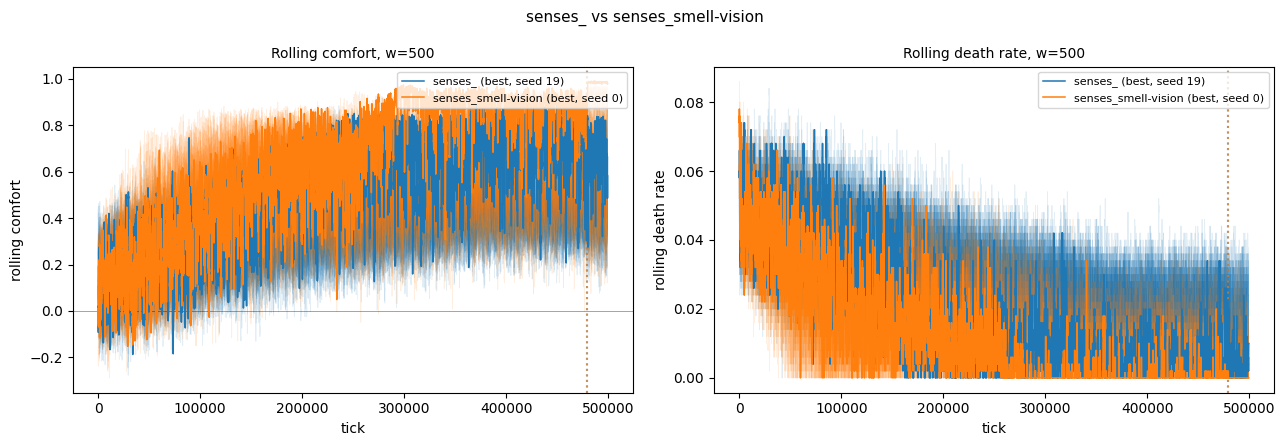

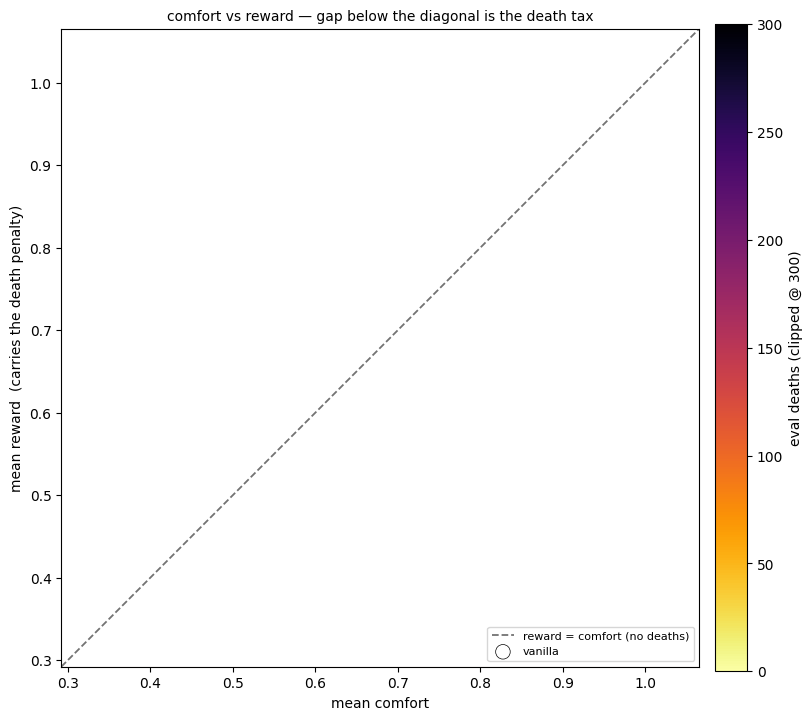

C:\Users\Adarsh Arun\AppData\Local\Temp\ipykernel_23928\1928936418.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


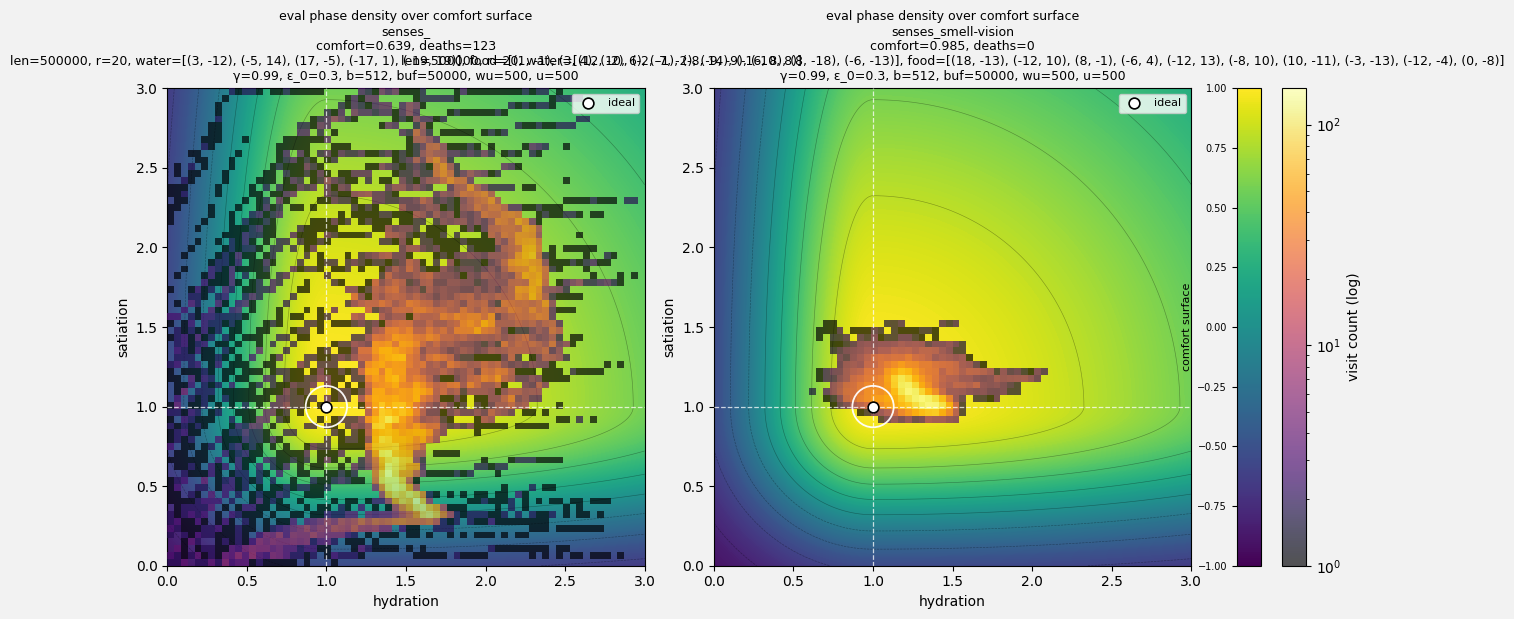

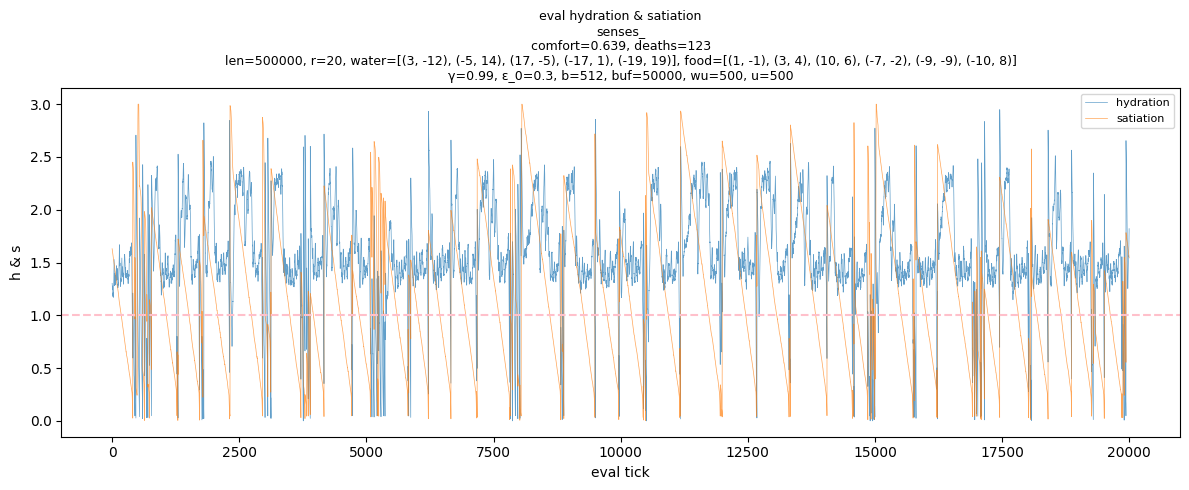

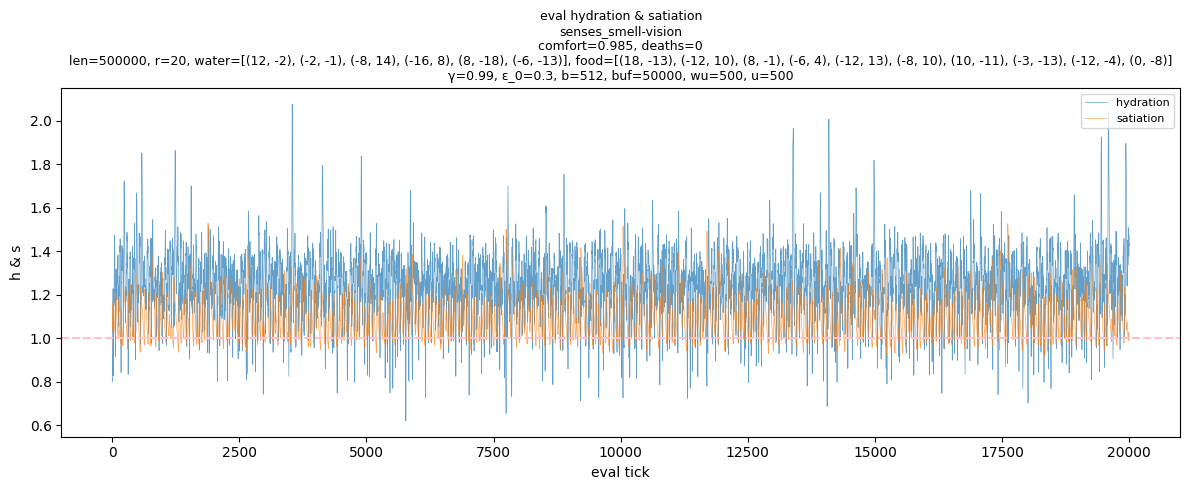

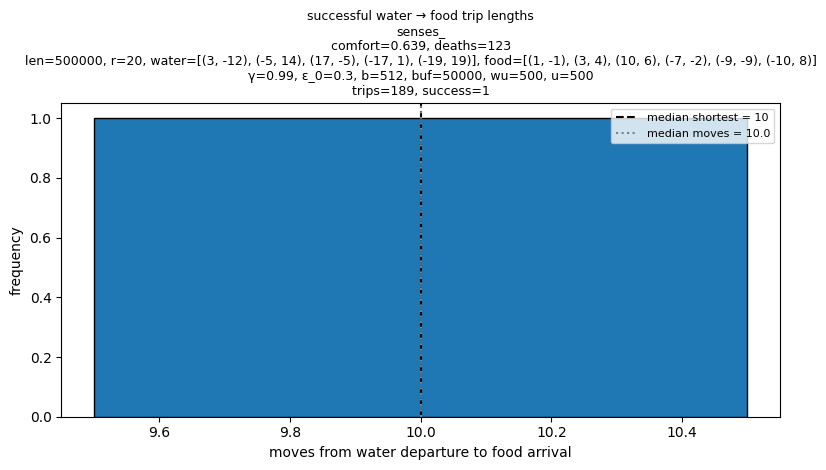

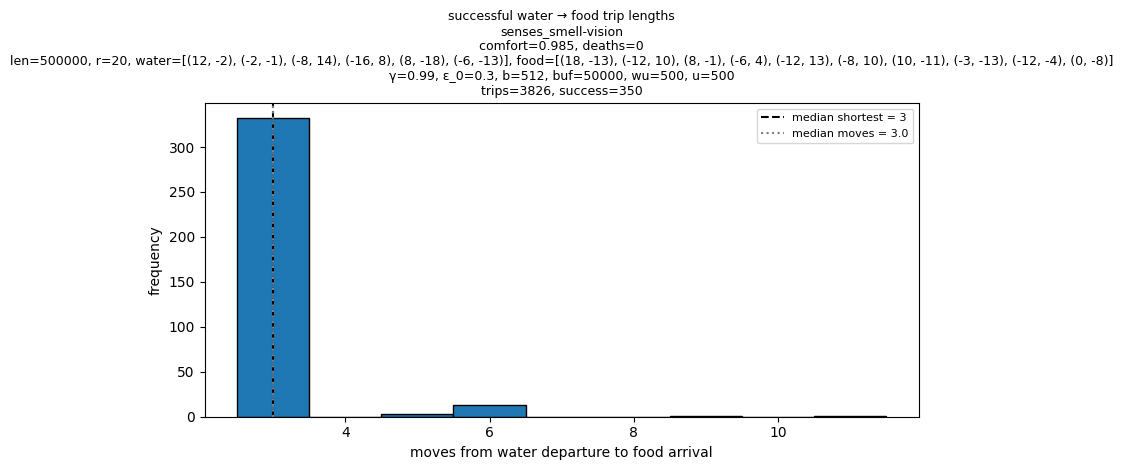

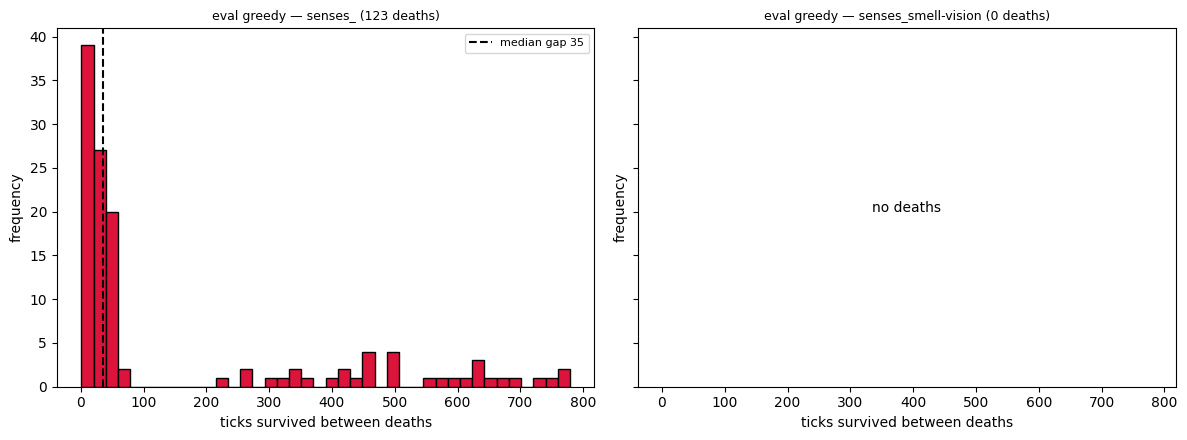

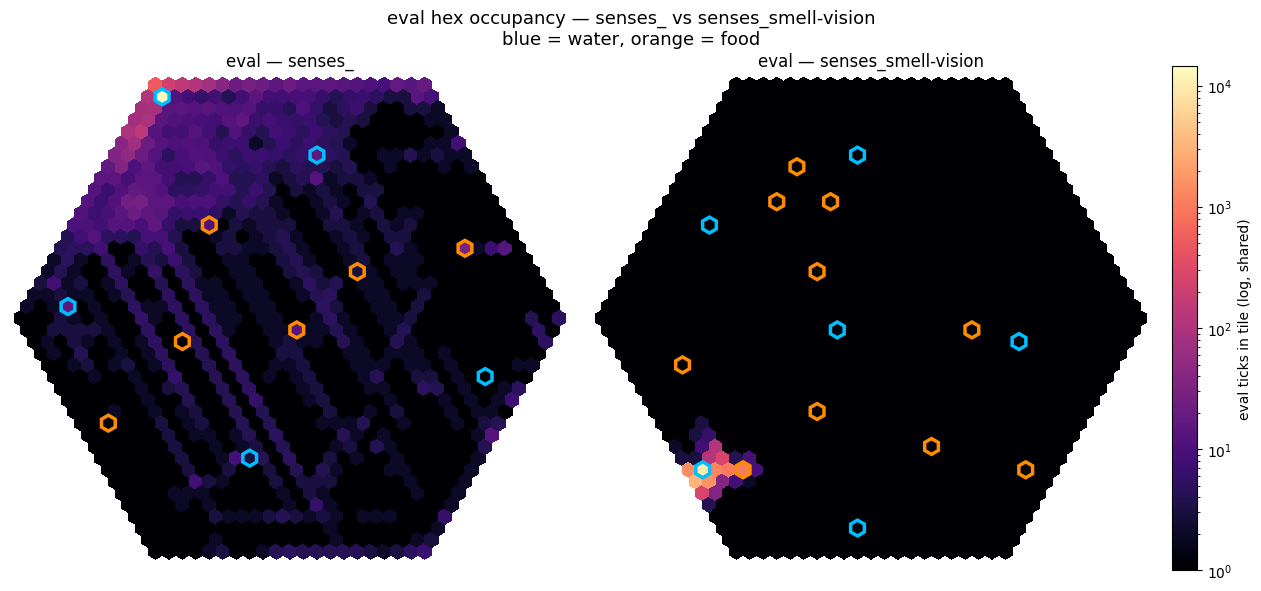

In [8]:
#region PLOT COMPARISON

def print_available_configs():
    print("available configs:")

    for i, name in enumerate(res.keys()):
        ranked = res[name]["ranked"]
        median = res[name]["median"]

        print(
            f"{i}: {name} | "
            f"n={len(ranked)} | "
            f"median comfort={median['mean_comfort']:.3f} | "
            f"median-run deaths={median['death_count_eval']}"
        )

def choose_configs():
    names = list(res.keys())

    print_available_configs()
    sel = input("Select runs, comma-separated e.g. 0,1: ")

    idxs = [int(x.strip()) for x in sel.split(",") if x.strip() != ""]

    if len(idxs) < 1:
        raise ValueError("Select at least one config.")

    for i in idxs:
        if i < 0 or i >= len(names):
            raise IndexError(f"Config index out of range: {i}")

    return [names[i] for i in idxs]


NAMES = choose_configs()
PICK = "best"


plot_sigma_decay_compare(NAMES, res_obj=res)

def rolling_mean(x, window):
    x = np.asarray(x, dtype=float)

    if window <= 0:
        raise ValueError("window must be positive")

    if len(x) < window:
        return np.array([])

    c = np.cumsum(np.insert(x, 0, 0.0))
    return (c[window:] - c[:-window]) / window


def draw_rolling(ax, series, key, window, ymarks=()):
    # background seed haze
    for s in series:
        for run in s["bg"]:
            ax.plot(
                rolling_mean(run[key], window),
                color=s["haze"],
                lw=0.6,
                alpha=0.12,
                zorder=1,
            )

    # selected representative run
    for s in series:
        run = s["run"]
        ax.plot(
            rolling_mean(run[key], window),
            color=s["color"],
            lw=1.1,
            zorder=3,
            label=s["label"],
        )

        eb_roll = max(0, eb_of(run) - window + 1)
        ax.axvline(
            eb_roll,
            ls=":",
            c=s["color"],
            alpha=0.6,
            zorder=2,
        )

    for y in ymarks:
        ax.axhline(y, ls="-", c="black", lw=0.5, alpha=0.5)

    ax.legend(fontsize=8, loc="upper right")



def safe_fig_name(prefix, names):
    joined = "_vs_".join(names)
    joined = joined.replace(" ", "_").replace("/", "-").replace("//", "-")
    return f"{prefix}_{joined}"


def build_comparison_series(names, pick, colors):
    picked = [(name, pick_run(name, pick=pick, res_obj=res)) for name in names]

    series = []
    for i, (name, run) in enumerate(picked):
        color = colors[i % len(colors)]
        haze = color if len(picked) > 1 else "gray"

        series.append({
            "bg": res[name]["ranked"],
            "run": run,
            "color": color,
            "haze": haze,
            "label": f"{name} ({pick}, seed {run['seed']})",
        })

    return picked, series


def plot_comparison(
    names,
    pick="median",
    window=500,
    save=False,
    colors=("tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown"),
):
    picked, series = build_comparison_series(names, pick, colors)

    # rolling comfort + death rate
    fig, (ax_c, ax_d) = plt.subplots(1, 2, figsize=(13, 4.5))

    draw_rolling(ax_c, series, "comfort_T", window, ymarks=(0,))
    ax_c.set_title(f"Rolling comfort, w={window}", fontsize=10)
    ax_c.set_xlabel("tick")
    ax_c.set_ylabel("rolling comfort")

    draw_rolling(ax_d, series, "death_T", window)
    ax_d.set_title(f"Rolling death rate, w={window}", fontsize=10)
    ax_d.set_xlabel("tick")
    ax_d.set_ylabel("rolling death rate")

    fig.suptitle(" vs ".join(names), fontsize=11)
    plt.tight_layout()

    plot_comfort_vs_reward(NAMES, res_obj=res)       # or just your selected ones

    if save:
        _save_fig(fig, safe_fig_name("cmp_rolling", names))

    plt.show()

    # phase density
    from matplotlib.gridspec import GridSpec

    n = len(picked)
    fig = plt.figure(figsize=(6.8 * n + 1.4, 6.2))
    gs  = GridSpec(1, n + 2,
                width_ratios=[*([1] * n), 0.045, 0.045],
                wspace=0.08, figure=fig)

    plot_axes  = [fig.add_subplot(gs[0, i]) for i in range(n)]
    cax_surf   = fig.add_subplot(gs[0, n])
    cax_dens   = fig.add_subplot(gs[0, n + 1])

    surf_m = dens_m = None
    for (name, run), ax in zip(picked, plot_axes):
        s, d = plot_phase_heatmap(run, name=name, ax=ax)
        surf_m = surf_m or s
        dens_m = dens_m or d          # first non-None density scale wins

    cbar_s = fig.colorbar(surf_m, cax=cax_surf)
    cbar_s.ax.yaxis.set_ticks_position('left')
    cbar_s.ax.yaxis.set_label_position('left')
    cbar_s.set_label("comfort surface", fontsize=8)
    cbar_s.set_ticks(np.linspace(-1, 1, 9))
    cbar_s.ax.tick_params(labelsize=7)

    if dens_m is not None:
        cbar_d = fig.colorbar(dens_m, cax=cax_dens)
        cbar_d.set_label("visit count (log)")

    plt.tight_layout()
    plt.show()

    # per-run diagnostics
    for name, run in picked:
        plot_eval_hs(run, name=name, save=save)

    for name, run in picked:
        plot_trip_lengths(run, name=name, save=save)

    # comparison diagnostics
    plot_death_gaps_eval_compare(picked, save=save)
    plot_hex_eval_compare(picked, save=save)


plot_comparison(NAMES, pick=PICK, window=500)

#endregion

In [ ]:
#region SUMMARY BLOCK

def fmt_pct(x, digits=1):
    if pd.isna(x):
        return "nan"
    return f"{100*x:.{digits}f}%"

def fmt_runtime(x):
    if pd.isna(x):
        return "nan"
    if "fmt_time" in globals():
        return fmt_time(x)
    return f"{x:.1f}s"

def fmt_num(x, digits=3):
    if pd.isna(x):
        return "nan"
    return f"{x:.{digits}f}"


def print_final_sweep_summary(summary_df, runs_df, experiment_name, PROTOTYPE_NAME):
    if summary_df.empty:
        print("No summary data loaded.")
        return

    print("=" * 90)
    print(f"FINAL SWEEP SUMMARY: {experiment_name}")
    print("=" * 90)

    print("\nConfigs tested:")
    print(f"  configs: {summary_df['config'].nunique()}")
    print(f"  total runs: {len(runs_df)}")
    print(f"  seeds per config: {int(summary_df['n_seeds'].median())}")

    print("\nCompact summary table:")
    cols = [
        "config",
        "n_seeds",
        "sim_len",
        "run_time_seconds_median",
        #"seconds_per_100k_ticks_median",
        #"ticks_per_second_median",
        "mean_comfort_median",
        "mean_comfort_std",
        "eval_deaths_median",
        "zero_death_rate",
        "food_visit_pct_median",
        "water_visit_pct_median",
        "path_efficiency_median",
        "perfectish_trip_rate_median",
        "solved_rate",
    ]

    table = summary_df[cols].copy()

    table["mean_comfort_median"] = table["mean_comfort_median"].map(lambda x: round(x, 3))
    table["mean_comfort_std"] = table["mean_comfort_std"].map(lambda x: round(x, 3) if not pd.isna(x) else np.nan)
    table["eval_deaths_median"] = table["eval_deaths_median"].map(lambda x: round(x, 1))
    table["zero_death_rate"] = table["zero_death_rate"].map(lambda x: f"{100*x:.0f}%")
    table["food_visit_pct_median"] = table["food_visit_pct_median"].map(lambda x: round(x, 1))
    table["water_visit_pct_median"] = table["water_visit_pct_median"].map(lambda x: round(x, 1))
    table["path_efficiency_median"] = table["path_efficiency_median"].map(lambda x: round(x, 3) if not pd.isna(x) else np.nan)
    table["perfectish_trip_rate_median"] = table["perfectish_trip_rate_median"].map(lambda x: f"{100*x:.0f}%" if not pd.isna(x) else "nan")
    table["solved_rate"] = table["solved_rate"].map(lambda x: f"{100*x:.0f}%")
    table["run_time_seconds_median"] = table["run_time_seconds_median"].map(fmt_runtime)
    #table["seconds_per_100k_ticks_median"] = table["seconds_per_100k_ticks_median"].map(lambda x: round(x, 2) if not pd.isna(x) else np.nan)
    #table["ticks_per_second_median"] = table["ticks_per_second_median"].map(lambda x: round(x, 1) if not pd.isna(x) else np.nan)

    print(table.to_string(index=False))

    print("\n" + "-" * 90)
    print("Winners / notable configs")
    print("-" * 90)

    best_comfort = summary_df.sort_values(
        ["mean_comfort_median", "mean_comfort_std"],
        ascending=[False, True],
    ).iloc[0]

    best_stability = summary_df.sort_values(
        ["mean_comfort_std", "mean_comfort_median"],
        ascending=[True, False],
    ).iloc[0]

    best_deaths = summary_df.sort_values(
        ["zero_death_rate", "eval_deaths_median", "mean_comfort_median"],
        ascending=[False, True, False],
    ).iloc[0]

    best_path = summary_df.sort_values(
        ["path_efficiency_median", "perfectish_trip_rate_median", "mean_comfort_median"],
        ascending=[False, False, False],
    ).iloc[0]

    best_solved = summary_df.sort_values(
        ["solved_rate", "mean_comfort_median", "path_efficiency_median"],
        ascending=[False, False, False],
    ).iloc[0]

    #best_runtime_efficiency = summary_df.sort_values(
    #["seconds_per_100k_ticks_median", "mean_comfort_median"],
    #ascending=[True, False],
    #).iloc[0]

    print(f"\nBest median comfort:")
    print(f"  {best_comfort['config']}")
    print(f"  median comfort = {best_comfort['mean_comfort_median']:.3f}")
    print(f"  std comfort    = {best_comfort['mean_comfort_std']:.3f}")

    print(f"\nMost stable comfort:")
    print(f"  {best_stability['config']}")
    print(f"  std comfort    = {best_stability['mean_comfort_std']:.3f}")
    print(f"  median comfort = {best_stability['mean_comfort_median']:.3f}")

    print(f"\nBest death robustness:")
    print(f"  {best_deaths['config']}")
    print(f"  zero-death rate     = {100*best_deaths['zero_death_rate']:.0f}%")
    print(f"  median eval deaths  = {best_deaths['eval_deaths_median']:.1f}")

    print(f"\nBest path efficiency:")
    print(f"  {best_path['config']}")
    print(f"  path efficiency        = {best_path['path_efficiency_median']:.3f}")
    print(f"  perfect-ish trip rate  = {100*best_path['perfectish_trip_rate_median']:.0f}%")

    print(f"\nBest overall solved rate:")
    print(f"  {best_solved['config']}")
    print(f"  solved rate      = {100*best_solved['solved_rate']:.0f}%")
    print(f"  median comfort   = {best_solved['mean_comfort_median']:.3f}")
    print(f"  path efficiency  = {best_solved['path_efficiency_median']:.3f}")
    print(f"\nBest runtime efficiency:")
    #print(f"  {best_runtime_efficiency['config']}")
    #print(f"  seconds per 100k      = {best_runtime_efficiency['seconds_per_100k_ticks_median']:.2f}")
    #print(f"  median comfort        = {best_runtime_efficiency['mean_comfort_median']:.3f}")

    print("\n" + "-" * 90)

    print("\nSaved files:")
    out = sweep_dir(experiment_name, PROTOTYPE_NAME=PROTOTYPE_NAME)
    print(f"  runs CSV:    {out / 'runs_df.csv'}")
    print(f"  summary CSV: {out / 'summary_df.csv'}")


print_final_sweep_summary(summary_df, runs_df, EXPERIMENT_NAME, PROTOTYPE_NAME=PROTOTYPE_NAME)

#endregion

FINAL SWEEP SUMMARY: 03b_nstep_robust novelty_rewards_p05__Vanilla_vs_Noisy

Configs tested:
  configs: 4
  total runs: 20
  seeds per config: 5

Compact summary table:
                    config  n_seeds  sim_len run_time_seconds_median  mean_comfort_median  mean_comfort_std  eval_deaths_median zero_death_rate  food_visit_pct_median  water_visit_pct_median  path_efficiency_median perfectish_trip_rate_median solved_rate
novelty_rewards_F__vanilla        5   500000                  2m 55s                0.780             0.139                 6.0             40%                    2.5                    48.3                   0.909                         74%         40%
  novelty_rewards_T__noisy        5   500000                   3m 8s                0.881             0.121                 3.0             20%                    4.7                    48.8                   1.000                         92%         20%
  novelty_rewards_F__noisy        5   500000                  3m 1